
# SPL Inject-Recover Scan for Gamma Prior Sensitivity

## Goal
Quantify whether we recover the injected spectral index `gamma` in SPL simulations when changing the prior family.

## Experiment Design
1. Inject SPL truth on a grid of `(phi_true, gamma_true)`.
2. For each injected dataset, fit SPL with MALA under each prior type:
   - `weakly`
   - `flat`
   - `lognormal_gamma`
3. Evaluate gamma recovery metrics:
   - bias: `posterior_mean(gamma) - gamma_true`
   - 90% CI width
   - 90% CI coverage indicator
4. Aggregate over seeds and compare prior choices.

This notebook is intentionally focused on **gamma recovery**; model-comparison/Bayes-factor analysis is optional and separated at the end.


In [5]:

import copy
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from load_config import load_config
from simulator import generate_single_season
from samplers import (
    run_mala,
    run_multiple_chains,
    build_spectral_logpost_and_grad,
    make_theta_init_for_model,
    posterior_summary_multi,
    _stack_chains,
    split_rhat,
)


In [6]:

cfg = load_config()

signal_cfg = cfg['signal']
bkg_cfg = cfg['background']
bins_cfg = cfg['energy_bins']
atmo_cfg = cfg['atmospheric_realism']
det_cfg = cfg['detector_response']
phys_prior = cfg['priors']['physics']
test_cfg = cfg['testing']
mala_cfg = cfg['samplers']['MALA']

# ---- Core scan controls ----
PRIOR_TYPES = ['weakly', 'flat', 'lognormal_gamma']
RECOVER_MODEL = 'power_law'  # keep inference model fixed for clean prior-sensitivity test

N_CHAINS = int(test_cfg.get('n_chains', 4))
FAST_MODE = False
USE_CACHE_IF_AVAILABLE = False

# MALA settings (override in fast mode)
N_ITER = int(mala_cfg['n_iterations'])
N_BURN = int(mala_cfg['n_burnin'])

PHI_BASE = float(signal_cfg['phi'])
if FAST_MODE:
    N_ITER = 4000
    N_BURN = 1000
    PHI_MULTS = np.array([0.3, 1.0, 3.0])
    GAMMA_VALS = np.array([2.2, 2.5, 2.8])
    SEEDS = list(range(3))
else:
    PHI_MULTS = np.array([0.3, 0.5, 1.0, 2.0, 3.0])
    GAMMA_VALS = np.array([2.1, 2.3, 2.5, 2.7, 2.9])
    SEEDS = list(range(5))

CACHE_DIR = Path('results/spl_scan_cache')
CACHE_DIR.mkdir(parents=True, exist_ok=True)
DF_FILE = CACHE_DIR / 'prior_scan_df.pkl'
AGG_FILE = CACHE_DIR / 'prior_scan_agg.pkl'
CHECKPOINT_EVERY = 10

print('Recover model:', RECOVER_MODEL)
print('Prior types:', PRIOR_TYPES)
print('Grid: |phi|={}, |gamma|={}, |seed|={}'.format(len(PHI_MULTS), len(GAMMA_VALS), len(SEEDS)))
print('Total fits:', len(PRIOR_TYPES) * len(PHI_MULTS) * len(GAMMA_VALS) * len(SEEDS))
print('Per fit: chains={}, iter={}, burn={}'.format(N_CHAINS, N_ITER, N_BURN))


Recover model: power_law
Prior types: ['weakly', 'flat', 'lognormal_gamma']
Grid: |phi|=5, |gamma|=5, |seed|=5
Total fits: 375
Per fit: chains=4, iter=30000, burn=10000


In [7]:

def compute_max_rhat(results):
    stacked = _stack_chains(results)
    rhats = []
    for j in range(stacked.shape[2]):
        # _stack_chains shape is (n_chains, n_samples, d)
        rhats.append(split_rhat(stacked[:, :, j]))
    return float(np.nanmax(rhats))


def generate_dataset(phi_true, gamma_true, seed):
    rng = np.random.default_rng(seed)
    return generate_single_season(
        phi=float(phi_true),
        gamma=float(gamma_true),
        eta=float(bkg_cfg['eta']),
        delta=float(bkg_cfg['delta']),
        truth_model='power_law',
        n_bins=int(bins_cfg['n_bins']),
        E_min=float(bins_cfg['E_min']),
        E_max=float(bins_cfg['E_max']),
        atmo_model=atmo_cfg['model'],
        prompt_fraction=float(atmo_cfg['prompt_fraction']),
        eta_prompt=float(bkg_cfg.get('eta_prompt', float(bkg_cfg['eta']) * float(atmo_cfg['prompt_fraction']))),
        infer_prompt_eta=True,
        delta_prompt=float(atmo_cfg['delta_prompt']),
        E_knee=float(atmo_cfg['E_knee']),
        knee_sharpness=float(atmo_cfg['knee_sharpness']),
        prompt_prior_log_mean=float(atmo_cfg['prompt_prior_log_mean']),
        prompt_prior_log_sd=float(atmo_cfg['prompt_prior_log_sd']),
        prior_phi_log_mean=float(phys_prior['phi_log_mean']),
        prior_phi_log_sd=float(phys_prior['phi_log_sd']),
        prior_gamma_mean=float(phys_prior['gamma_mean']),
        prior_gamma_sd=float(phys_prior['gamma_sd']),
        prior_eta_log_mean=float(phys_prior['eta_log_mean']),
        prior_eta_log_sd=float(phys_prior['eta_log_sd']),
        prior_delta_mean=float(phys_prior['delta_mean']),
        prior_delta_sd=float(phys_prior['delta_sd']),
        detector_mode=det_cfg['mode'],
        livetime_years=float(det_cfg['livetime_years']),
        sigma_log10=float(det_cfg['sigma_log10']),
        physical_flux_units=bool(det_cfg.get('physical_flux_units', False)),
        hese75_aeff_allsky_path=det_cfg.get('hese75_aeff_allsky_path', None),
        hese75_migration_path=det_cfg.get('hese75_migration_path', None),
        hese75_sky_factor_sr=float(det_cfg.get('hese75_sky_factor_sr', 4.0 * np.pi)),
        rng=rng,
    )


def run_one_fit(ds, prior_type, seed):
    logpost, gradpost, param_names = build_spectral_logpost_and_grad(
        ds,
        recover_model=RECOVER_MODEL,
        prior_type=prior_type,
        eps=1e-5,
    )
    theta_init = make_theta_init_for_model(ds, RECOVER_MODEL, param_names, signal_cfg)

    results = run_multiple_chains(
        run_mala,
        theta_init=theta_init,
        n_chains=N_CHAINS,
        init_strategy='jitter',
        init_scale=float(test_cfg.get('init_scale_base', 0.05)),
        rng=np.random.default_rng(seed + 77),
        log_posterior_fn=logpost,
        grad_log_posterior_fn=gradpost,
        n_iterations=N_ITER,
        n_burnin=N_BURN,
        step_size=float(mala_cfg['step_size']),
        adapt_step=bool(mala_cfg['adapt_step']),
        adapt_until=min(int(mala_cfg['adapt_until']), N_BURN),
        adapt_interval=int(mala_cfg['adapt_interval']),
        target_accept=float(mala_cfg['target_accept']),
        param_names=param_names,
        precond_type=mala_cfg['precond_type'],
        adapt_precond=bool(mala_cfg['adapt_precond']),
        normalize_precond=bool(mala_cfg['normalize_precond']),
        verbose=False,
    )

    summary = posterior_summary_multi(results, ci=0.90, true_values=None)

    g_mean = float(summary['gamma']['mean'])
    g_lo = float(summary['gamma']['ci_lower'])
    g_hi = float(summary['gamma']['ci_upper'])
    g_true = float(ds.true_params['gamma'])

    return {
        'gamma_post_mean': g_mean,
        'gamma_ci_lo': g_lo,
        'gamma_ci_hi': g_hi,
        'gamma_ci_width': g_hi - g_lo,
        'gamma_bias': g_mean - g_true,
        'gamma_covered_90': float(g_lo <= g_true <= g_hi),
        'accept_rate': float(np.mean([r.acceptance_rate for r in results])),
        'rhat_max': compute_max_rhat(results),
        'n_events': int(ds.counts.sum()),
    }


In [8]:

# Run scan or load cache (with periodic checkpointing)
if USE_CACHE_IF_AVAILABLE and DF_FILE.exists():
    with open(DF_FILE, 'rb') as f:
        df = pickle.load(f)
    print(f'Loaded cache: {len(df)} rows from {DF_FILE}')
else:
    if DF_FILE.exists():
        with open(DF_FILE, 'rb') as f:
            df_partial = pickle.load(f)
        rows = df_partial.to_dict('records')
        print(f'Resuming from partial cache: {len(rows)} rows from {DF_FILE}')
    else:
        rows = []

    done_keys = {
        (str(r['prior_type']), float(r['phi_mult']), float(r['gamma_true']), int(r['seed']))
        for r in rows
    }

    completed = len(rows)
    for prior_type in PRIOR_TYPES:
        for phi_mult in PHI_MULTS:
            phi_true = PHI_BASE * float(phi_mult)
            for gamma_true in GAMMA_VALS:
                for seed in SEEDS:
                    key = (str(prior_type), float(phi_mult), float(gamma_true), int(seed))
                    if key in done_keys:
                        continue

                    run_seed = 10_000 + int(seed)
                    ds = generate_dataset(phi_true, float(gamma_true), run_seed)
                    out = run_one_fit(ds, prior_type, run_seed)
                    rows.append({
                        'prior_type': prior_type,
                        'phi_mult': float(phi_mult),
                        'phi_true': float(phi_true),
                        'gamma_true': float(gamma_true),
                        'seed': int(seed),
                        **out,
                    })
                    done_keys.add(key)
                    completed += 1
                    print(f"done prior={prior_type:15s} phi_mult={phi_mult:>4} gamma={gamma_true:>3} seed={seed}")

                    if (completed % CHECKPOINT_EVERY) == 0:
                        df_ckpt = pd.DataFrame(rows)
                        with open(DF_FILE, 'wb') as f:
                            pickle.dump(df_ckpt, f)
                            f.flush()
                        print(f'Checkpoint saved ({completed} rows): {DF_FILE}')

    df = pd.DataFrame(rows)
    with open(DF_FILE, 'wb') as f:
        pickle.dump(df, f)
        f.flush()
    print(f'Saved cache: {DF_FILE}')

Path('results').mkdir(exist_ok=True)
df.to_csv('results/spl_prior_scan_runs.csv', index=False)
print('Saved results/spl_prior_scan_runs.csv')
print('Rows:', len(df))
df.head()


Resuming from partial cache: 81 rows from results/spl_scan_cache/prior_scan_df.pkl
done prior=weakly          phi_mult= 0.3 gamma=2.1 seed=0
done prior=weakly          phi_mult= 0.3 gamma=2.1 seed=1
done prior=weakly          phi_mult= 0.3 gamma=2.1 seed=2
done prior=weakly          phi_mult= 0.3 gamma=2.1 seed=3
done prior=weakly          phi_mult= 0.3 gamma=2.1 seed=4
done prior=weakly          phi_mult= 0.3 gamma=2.3 seed=0
done prior=weakly          phi_mult= 0.3 gamma=2.3 seed=1
done prior=weakly          phi_mult= 0.3 gamma=2.3 seed=2
done prior=weakly          phi_mult= 0.3 gamma=2.3 seed=3
Checkpoint saved (90 rows): results/spl_scan_cache/prior_scan_df.pkl
done prior=weakly          phi_mult= 0.3 gamma=2.3 seed=4
done prior=weakly          phi_mult= 0.3 gamma=2.5 seed=3
done prior=weakly          phi_mult= 0.3 gamma=2.5 seed=4
done prior=weakly          phi_mult= 0.3 gamma=2.7 seed=0
done prior=weakly          phi_mult= 0.3 gamma=2.7 seed=1
done prior=weakly          phi_mult=

,prior_type,phi_mult,phi_true,gamma_true,seed,gamma_post_mean,gamma_ci_lo,gamma_ci_hi,gamma_ci_width,gamma_bias,gamma_covered_90,accept_rate,rhat_max,n_events
0,weakly,0.3,6.180000e-19,2.2,0,2.336246,2.101532,2.613120,0.511588,0.136246,1.0,0.992500,2.504853,965
1,weakly,0.3,6.180000e-19,2.2,1,2.487301,2.203877,2.877527,0.673650,0.287301,0.0,0.994500,2.531171,978
2,weakly,0.3,6.180000e-19,2.2,2,2.250041,1.996461,2.468432,0.471972,0.050041,1.0,0.992563,2.468029,1016
3,weakly,0.3,6.180000e-19,2.5,0,2.650566,2.286720,3.279098,0.992378,0.150566,1.0,0.992750,2.368543,950
4,weakly,0.3,6.180000e-19,2.5,1,2.719884,2.395167,3.120042,0.724875,0.219884,1.0,0.994563,2.497574,969


In [9]:

# Aggregate over seeds (main comparison table)
agg = (
    df.groupby(['prior_type', 'phi_mult', 'phi_true', 'gamma_true'], as_index=False)
      .agg(
          n_events_mean=('n_events', 'mean'),
          gamma_bias_mean=('gamma_bias', 'mean'),
          gamma_bias_abs_mean=('gamma_bias', lambda x: float(np.mean(np.abs(x)))),
          gamma_ci_width_mean=('gamma_ci_width', 'mean'),
          gamma_coverage_90=('gamma_covered_90', 'mean'),
          accept_rate_mean=('accept_rate', 'mean'),
          rhat_max_worst=('rhat_max', 'max'),
      )
)

with open(AGG_FILE, 'wb') as f:
    pickle.dump(agg, f)
agg.to_csv('results/spl_prior_scan_agg.csv', index=False)
print('Saved results/spl_prior_scan_agg.csv')

print('Coverage target for 90% CI is near 0.90.')
agg.head(12)


Saved results/spl_prior_scan_agg.csv
Coverage target for 90% CI is near 0.90.


,prior_type,phi_mult,phi_true,gamma_true,n_events_mean,gamma_bias_mean,gamma_bias_abs_mean,gamma_ci_width_mean,gamma_coverage_90,accept_rate_mean,rhat_max_worst
0,flat,0.3,6.180000e-19,2.1,991.400000,0.450784,0.521306,1.889248,0.8,0.604880,1.430667
1,flat,0.3,6.180000e-19,2.2,986.333333,0.133120,0.169268,0.679877,1.0,0.993313,2.654149
2,flat,0.3,6.180000e-19,2.3,978.800000,0.934468,0.934468,2.284179,0.8,0.618577,1.510991
3,flat,0.3,6.180000e-19,2.5,969.000000,0.589572,0.589572,1.593942,0.8,0.836364,2.955016
4,flat,0.3,6.180000e-19,2.7,959.200000,0.903938,0.903938,1.696015,0.6,0.597837,1.471288
5,flat,0.3,6.180000e-19,2.8,964.333333,0.270521,0.270521,1.390180,1.0,0.993375,3.083251
6,flat,0.3,6.180000e-19,2.9,960.800000,0.634927,0.634927,1.443367,0.6,0.598120,1.269871
7,flat,0.5,1.030000e-18,2.1,1041.200000,0.322769,0.358347,1.630014,1.0,0.608847,1.453575
8,flat,0.5,1.030000e-18,2.3,1017.400000,0.796146,0.796146,2.428789,1.0,0.634497,1.413083
9,flat,0.5,1.030000e-18,2.5,1002.600000,0.860310,0.860310,1.968642,0.6,0.585583,1.536049


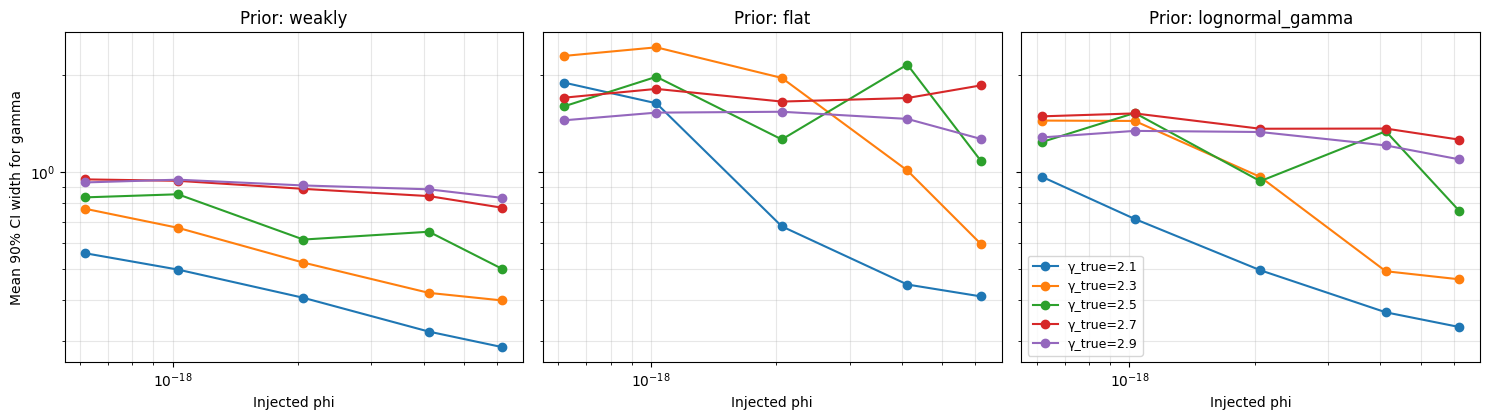

In [10]:

# Plot 1: Gamma CI width vs injected phi (faceted by prior)
fig, axes = plt.subplots(1, len(PRIOR_TYPES), figsize=(5*len(PRIOR_TYPES), 4.3), sharey=True)
if len(PRIOR_TYPES) == 1:
    axes = [axes]

for ax, prior_type in zip(axes, PRIOR_TYPES):
    subp = agg[agg['prior_type'] == prior_type]
    for g in sorted(GAMMA_VALS):
        sub = subp[subp['gamma_true'] == g].sort_values('phi_true')
        ax.loglog(sub['phi_true'], sub['gamma_ci_width_mean'], 'o-', label=f'γ_true={g}')
    ax.set_title(f'Prior: {prior_type}')
    ax.set_xlabel('Injected phi')
    ax.grid(True, alpha=0.3, which='both')

axes[0].set_ylabel('Mean 90% CI width for gamma')
axes[-1].legend(fontsize=9)
plt.tight_layout()
plt.show()


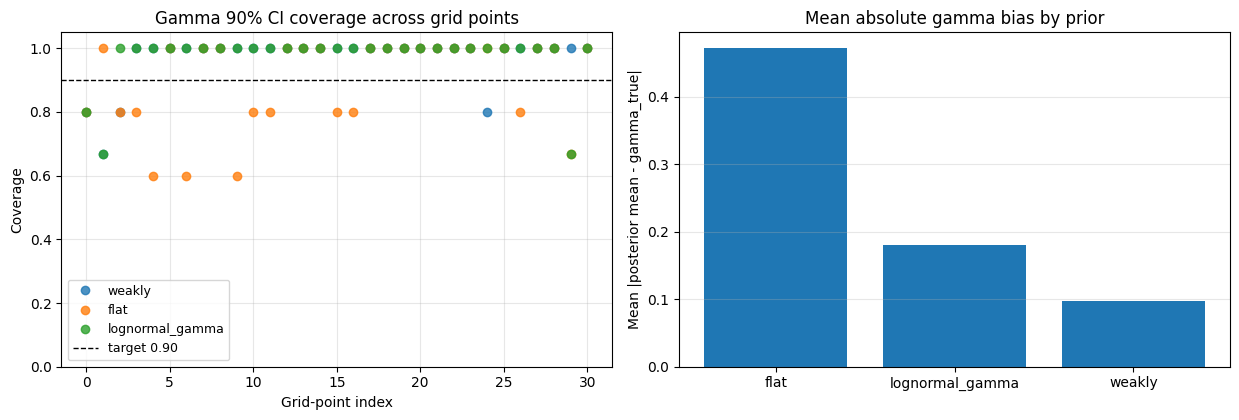

,prior_type,mean_abs_bias,mean_ci_width,mean_coverage,worst_rhat
0,flat,0.471934,1.346756,0.898925,4.637778
1,lognormal_gamma,0.180385,0.982492,0.972043,3.948328
2,weakly,0.096828,0.657638,0.969892,3.171709


In [11]:

# Plot 2: Coverage and bias by prior
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))

ax = axes[0]
for prior_type in PRIOR_TYPES:
    sub = agg[agg['prior_type'] == prior_type]
    x = np.arange(len(sub))
    ax.plot(x, sub['gamma_coverage_90'].values, 'o', label=prior_type, alpha=0.8)
ax.axhline(0.90, color='k', linestyle='--', linewidth=1.0, label='target 0.90')
ax.set_title('Gamma 90% CI coverage across grid points')
ax.set_ylabel('Coverage')
ax.set_xlabel('Grid-point index')
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=9)

ax = axes[1]
summary_prior = (
    agg.groupby('prior_type', as_index=False)
       .agg(
           mean_abs_bias=('gamma_bias_abs_mean', 'mean'),
           mean_ci_width=('gamma_ci_width_mean', 'mean'),
           mean_coverage=('gamma_coverage_90', 'mean'),
           worst_rhat=('rhat_max_worst', 'max'),
       )
)
ax.bar(summary_prior['prior_type'], summary_prior['mean_abs_bias'])
ax.set_title('Mean absolute gamma bias by prior')
ax.set_ylabel('Mean |posterior mean - gamma_true|')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()
summary_prior



## Interpretation Checklist
Use this checklist to decide if recovery is acceptable:

- Coverage: each prior should have mean `gamma_coverage_90` close to `0.90`.
- Bias: `mean_abs_bias` should be small and stable across grid points.
- Precision: `gamma_ci_width_mean` should shrink at higher injected `phi`.
- Convergence: `rhat_max_worst` should stay close to `1.0` (typically `< 1.05`).

If one prior has better precision but poor coverage, treat it as potentially overconfident.


In [12]:

# Optional: compact pivot tables for reporting
pivot_cov = agg.pivot_table(index=['phi_mult', 'gamma_true'], columns='prior_type', values='gamma_coverage_90')
pivot_bias = agg.pivot_table(index=['phi_mult', 'gamma_true'], columns='prior_type', values='gamma_bias_mean')

print('Coverage (90% CI):')
display(pivot_cov)
print('Bias (posterior mean - truth):')
display(pivot_bias)


Coverage (90% CI):


prior_type               flat  lognormal_gamma    weakly
phi_mult gamma_true                                     
0.3      2.1         0.800000         0.800000  0.800000
         2.2         1.000000         0.666667  0.666667
         2.3         0.800000         1.000000  0.800000
         2.5         0.800000         1.000000  1.000000
         2.7         0.600000         1.000000  1.000000
         2.8         1.000000         1.000000  1.000000
         2.9         0.600000         1.000000  1.000000
0.5      2.1         1.000000         1.000000  1.000000
         2.3         1.000000         1.000000  1.000000
         2.5         0.600000         1.000000  1.000000
         2.7         0.800000         1.000000  1.000000
         2.9         0.800000         1.000000  1.000000
1.0      2.1         1.000000         1.000000  1.000000
         2.2         1.000000         1.000000  1.000000
         2.3         1.000000         1.000000  1.000000
         2.5         0.800000         1.000000  1.000000
         2.7         0.800000         1.000000  1.000000
         2.8         1.000000         1.000000  1.000000
         2.9         1.000000         1.000000  1.000000
2.0      2.1         1.000000         1.000000  1.000000
         2.3         1.000000         1.000000  1.000000
         2.5         1.000000         1.000000  1.000000
         2.7         1.000000         1.000000  1.000000
         2.9         1.000000         1.000000  1.000000
3.0      2.1         1.000000         1.000000  0.800000
         2.2         1.000000         1.000000  1.000000
         2.3         0.800000         1.000000  1.000000
         2.5         1.000000         1.000000  1.000000
         2.7         1.000000         1.000000  1.000000
         2.8         0.666667         0.666667  1.000000
         2.9         1.000000         1.000000  1.000000

Bias (posterior mean - truth):


prior_type               flat  lognormal_gamma    weakly
phi_mult gamma_true                                     
0.3      2.1         0.450784         0.224225  0.198201
         2.2         0.133120         0.137864  0.157863
         2.3         0.934468         0.328911  0.206361
         2.5         0.589572         0.272531  0.171258
         2.7         0.903938         0.328786  0.110499
         2.8         0.270521         0.047187 -0.026847
         2.9         0.634927         0.252784 -0.035616
0.5      2.1         0.322769         0.191490  0.184722
         2.3         0.796146         0.234980  0.123369
         2.5         0.860310         0.320049  0.111599
         2.7         0.836838         0.277982  0.024749
         2.9         0.648788         0.213609 -0.060938
1.0      2.1        -0.039773         0.041316  0.048738
         2.2        -0.015940        -0.001258 -0.008378
         2.3         0.499591         0.125011  0.063817
         2.5         0.435478         0.161379  0.041781
         2.7         0.781605         0.297317  0.034558
         2.8         0.398104         0.212290  0.070346
         2.9         0.591245         0.149796 -0.100546
2.0      2.1        -0.050901        -0.016409 -0.012288
         2.3        -0.050054        -0.046541 -0.048026
         2.5         0.669698         0.155234 -0.000624
         2.7         0.688781         0.229241 -0.025271
         2.9         0.534861         0.143516 -0.126154
3.0      2.1        -0.092157        -0.066843 -0.057197
         2.2        -0.033958        -0.027773 -0.040411
         2.3        -0.147403        -0.105904 -0.104018
         2.5         0.328963         0.082498  0.000993
         2.7         0.620435         0.156289 -0.057339
         2.8         0.293092         0.196522  0.053140
         2.9         0.457224         0.160594 -0.100195